# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib # بۆ سەیڤکردنی مۆدێلەکە بۆ وێبسایتەکەت



# ==========================================
# 1. Data Preparation (ئامادەکردنی داتا)
# ==========================================

In [4]:

df = pd.read_csv('transformer_data.csv')

# گۆڕینی دۆخی ئابووری و وەرزەکان بۆ شێوازی تێگەیشتنی ئامێر
df['Status_Encoded'] = df['Status'].map({'Low': 1, 'Middle': 2, 'High': 3})
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Peak_Load_kVA', 'Transformer_Size_kVA', 'Status'])
y = df['Peak_Load_kVA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# ==========================================
# 2. Hyperparameter Tuning & Model Training (ئۆپتیمایزکردن و فێرکردن)
# ==========================================


In [7]:
print("گەڕان بەدوای باشترین ڕێکخستنەکاندا (GridSearchCV) دەستی پێکرد، تکایە چاوەڕێ بە...")

# پێدانی چەندین بژاردە بە مۆدێلەکە بۆ ئەوەی خۆی تاقییان بکاتەوە
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10]
}

base_model = RandomForestRegressor(random_state=42)
# مۆدێلەکە ٥ جار تاقیکردنەوە دەکات بۆ هەر ڕێکخستنێک (Cross-Validation) بۆ دڵنیابوون
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# وەرگرتنی باشترین مۆدێل
best_rf_model = grid_search.best_estimator_
print(f"باشترین ڕێکخستن کە دۆزرایەوە:  {grid_search.best_params_}")


گەڕان بەدوای باشترین ڕێکخستنەکاندا (GridSearchCV) دەستی پێکرد، تکایە چاوەڕێ بە...
باشترین ڕێکخستن کە دۆزرایەوە:  {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 200}



# ==========================================
# 3. Model Saving (خەزنکردنی مۆدێلەکە بۆ وێبسایت)
# ==========================================


In [8]:
joblib.dump(best_rf_model, 'transformer_model.pkl')
print("مۆدێلەکە بە سەرکەوتوویی سەیڤ کرا وەک: transformer_model.pkl")


مۆدێلەکە بە سەرکەوتوویی سەیڤ کرا وەک: transformer_model.pkl



# ==========================================
# 4. Prediction & Evaluation (پێشبینی و هەڵسەنگاندن)
# ==========================================


In [9]:
y_test_pred = best_rf_model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n" + "="*50)
print("📊 ئەنجامی کۆتایی باشترین مۆدێل (Model Performance):")
print("="*50)
print(f"1️⃣ ڕێژەی سەرکەوتن (R² Score) : {r2_test:.4f}")
print(f"2️⃣ تێکڕای هەڵە (MAE)         : {mae_test:.2f} kVA")
print(f"3️⃣ ڕەگی دووجای هەڵە (RMSE)   : {rmse_test:.2f} kVA")
print("="*50 + "\n")



📊 ئەنجامی کۆتایی باشترین مۆدێل (Model Performance):
1️⃣ ڕێژەی سەرکەوتن (R² Score) : 0.9821
2️⃣ تێکڕای هەڵە (MAE)         : 17.74 kVA
3️⃣ ڕەگی دووجای هەڵە (RMSE)   : 24.77 kVA




# ==========================================
# 5. Visualization (گرافە پرۆفیشناڵەکان)
# ==========================================


C:\Users\Golden\AppData\Local\Temp\ipykernel_18008\1209166698.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, ax=axes[2], palette='viridis')


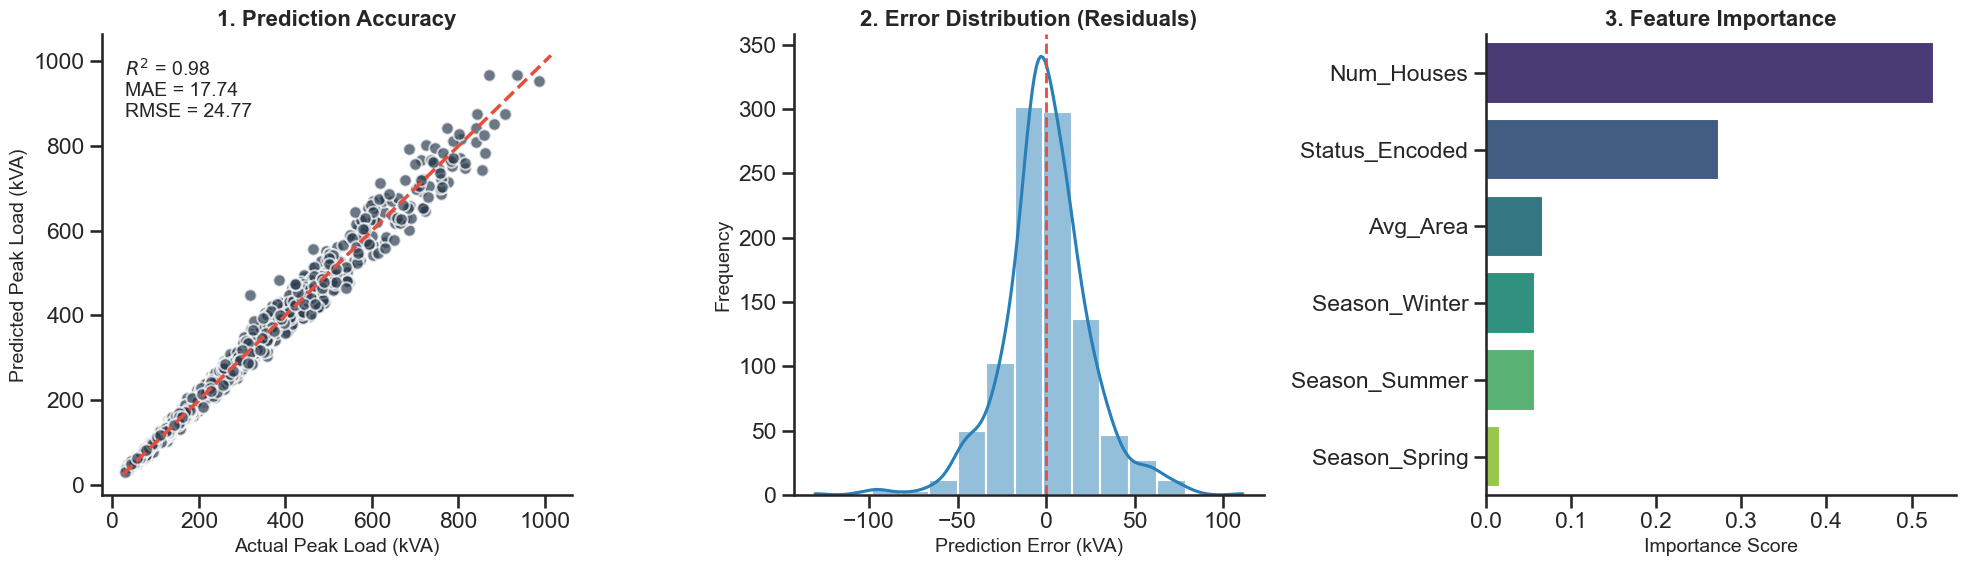

In [10]:
sns.set_theme(style="ticks", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.7, color='#2c3e50', edgecolor='white', s=80)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='#e74c3c', linestyle='--', linewidth=2.5)
axes[0].set_title('1. Prediction Accuracy', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Actual Peak Load (kVA)', fontsize=14)
axes[0].set_ylabel('Predicted Peak Load (kVA)', fontsize=14)
textstr = f'$R^2$ = {r2_test:.2f}\nMAE = {mae_test:.2f}\nRMSE = {rmse_test:.2f}'
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=14,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Residuals Distribution
residuals = y_test - y_test_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#2980b9', bins=15)
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_title('2. Error Distribution (Residuals)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Prediction Error (kVA)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# Plot 3: Feature Importance
importances = best_rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]

sns.barplot(x=sorted_importances, y=sorted_features, ax=axes[2], palette='viridis')
axes[2].set_title('3. Feature Importance', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Importance Score', fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()